# Macro AI Lakehouse - Gold Findings & Empirical Analysis

This notebook computes executive feature marts and visualizes the core empirical results:
1. **Macro Return Distributions & Volatility Grid** (Brent, EUR/USD, 10Y Yields)
2. **Geopolitical Event Study Trajectories** (Trading days -5 to +25)
3. **HAC OLS Regressions** (Tech CapEx growth vs. Macro Yield shifts)
4. **K-Means Labor Cluster Analysis** ($k=3$ wage, task intensity, automation pressure profiles & scatter plot)
5. **Labor Friction Matrix** (Augmentation vs. Administrative Drag 2x2 scatter plot & Quadrant 2 bottlenecks)

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set consistent plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 11})

# Standardize base and data directory paths
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
BRONZE_DIR = os.path.join(DATA_DIR, "bronze")
SILVER_DIR = os.path.join(DATA_DIR, "silver")
GOLD_DIR = os.path.join(DATA_DIR, "gold")
DB_PATH = os.path.join(DATA_DIR, "lakehouse.duckdb")

os.makedirs(GOLD_DIR, exist_ok=True)
con = duckdb.connect(DB_PATH)
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")
print(f"DuckDB database connected: {DB_PATH}")


DuckDB database connected: C:\Users\aabha\macro_ai_lakehouse\data\lakehouse.duckdb


## Gold Feature Marts Initialization

In [2]:
# Build gold.fct_labor_automation_pressure
con.execute("""
    CREATE OR REPLACE TABLE gold.fct_labor_automation_pressure AS
    WITH stats AS (
        SELECT 
            AVG(hourly_median_wage) AS avg_wage,
            STDDEV(hourly_median_wage) AS std_wage,
            AVG(onet_task_intensity_score) AS avg_task,
            STDDEV(onet_task_intensity_score) AS std_task
        FROM silver.dim_labor_occupations
    ),
    scored AS (
        SELECT 
            l.soc_code,
            l.occupation_title,
            l.soc_major_group,
            l.total_employment,
            l.hourly_median_wage,
            l.onet_task_intensity_score,
            ROUND(l.total_employment * (l.hourly_median_wage * 2080) / 1e9, 2) AS total_payroll_billions_usd,
            ROUND((l.hourly_median_wage - s.avg_wage) / s.std_wage, 3) AS wage_zscore,
            ROUND((l.onet_task_intensity_score - s.avg_task) / s.std_task, 3) AS task_zscore,
            ROUND((l.hourly_median_wage / s.avg_wage) * (l.onet_task_intensity_score / s.avg_task) * 100, 2) AS automation_pressure_index
        FROM silver.dim_labor_occupations l
        CROSS JOIN stats s
    )
    SELECT 
        *,
        DENSE_RANK() OVER (ORDER BY automation_pressure_index DESC) AS national_automation_rank,
        DENSE_RANK() OVER (PARTITION BY soc_major_group ORDER BY automation_pressure_index DESC) AS sector_automation_rank
    FROM scored;
""")

parquet_gold_labor = os.path.join(GOLD_DIR, "fct_labor_automation_pressure.parquet").replace("\\", "/")
con.execute(f"COPY gold.fct_labor_automation_pressure TO '{parquet_gold_labor}' (FORMAT PARQUET);")

# Build gold.fct_macro_regimes
con.execute("""
    CREATE OR REPLACE TABLE gold.fct_macro_regimes AS
    WITH rolling_macro AS (
        SELECT 
            month_date,
            gpr_index,
            brent_crude_monthly_avg,
            eur_usd_monthly_avg,
            us_10y_yield_monthly_avg,
            AVG(gpr_index) OVER (
                ORDER BY month_date 
                ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
            ) AS gpr_12m_rolling_avg,
            STDDEV(gpr_index) OVER (
                ORDER BY month_date 
                ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
            ) AS gpr_12m_rolling_std,
            ROUND(((LEAD(brent_crude_monthly_avg, 1) OVER (ORDER BY month_date) - brent_crude_monthly_avg) / brent_crude_monthly_avg) * 100, 2) AS brent_fwd_1m_pct,
            ROUND(((LEAD(eur_usd_monthly_avg, 1) OVER (ORDER BY month_date) - eur_usd_monthly_avg) / eur_usd_monthly_avg) * 100, 2) AS eur_usd_fwd_1m_pct,
            ROUND(LEAD(us_10y_yield_monthly_avg, 1) OVER (ORDER BY month_date) - us_10y_yield_monthly_avg, 2) AS treasury_10y_fwd_1m_diff
        FROM silver.fact_macro_monthly
    )
    SELECT 
        month_date,
        gpr_index,
        ROUND(gpr_12m_rolling_avg, 2) AS gpr_12m_rolling_avg,
        CASE 
            WHEN gpr_index >= (gpr_12m_rolling_avg + 1.5 * gpr_12m_rolling_std) THEN 1 
            ELSE 0 
        END AS is_geopolitical_shock_month,
        brent_crude_monthly_avg,
        brent_fwd_1m_pct,
        eur_usd_monthly_avg,
        eur_usd_fwd_1m_pct,
        us_10y_yield_monthly_avg,
        treasury_10y_fwd_1m_diff
    FROM rolling_macro
    ORDER BY month_date ASC;
""")

parquet_gold_macro = os.path.join(GOLD_DIR, "fct_macro_regimes.parquet").replace("\\", "/")
con.execute(f"COPY gold.fct_macro_regimes TO '{parquet_gold_macro}' (FORMAT PARQUET);")

# Build gold.fct_innovation_friction
con.execute("""
    CREATE OR REPLACE TABLE gold.fct_innovation_friction AS
    WITH quarterly_macro AS (
        SELECT 
            date_trunc('quarter', month_date) AS quarter_date,
            AVG(gpr_index) AS avg_gpr_index,
            MAX(is_geopolitical_shock_month) AS had_geopolitical_shock,
            AVG(brent_crude_monthly_avg) AS avg_brent_price,
            AVG(us_10y_yield_monthly_avg) AS avg_10y_yield
        FROM gold.fct_macro_regimes
        GROUP BY 1
    )
    SELECT 
        t.quarter_date,
        t.software_growth_qoq,
        t.rd_growth_qoq,
        t.total_ip_growth_qoq,
        m.avg_gpr_index,
        m.had_geopolitical_shock,
        m.avg_brent_price,
        m.avg_10y_yield,
        (m.avg_10y_yield - LAG(m.avg_10y_yield, 1) OVER (ORDER BY t.quarter_date)) AS yield_qoq_change
    FROM silver.fact_tech_investment t
    INNER JOIN quarterly_macro m ON t.quarter_date = m.quarter_date
    ORDER BY t.quarter_date ASC;
""")
print("Gold feature marts initialized.")


Gold feature marts initialized.


## 1. Daily Macro Distributions and 21-Day Realized Volatility Grid
Contrasts baseline market behavior with geopolitical shock regimes across Brent crude, EUR/USD spot FX, and 10Y Treasury yields.

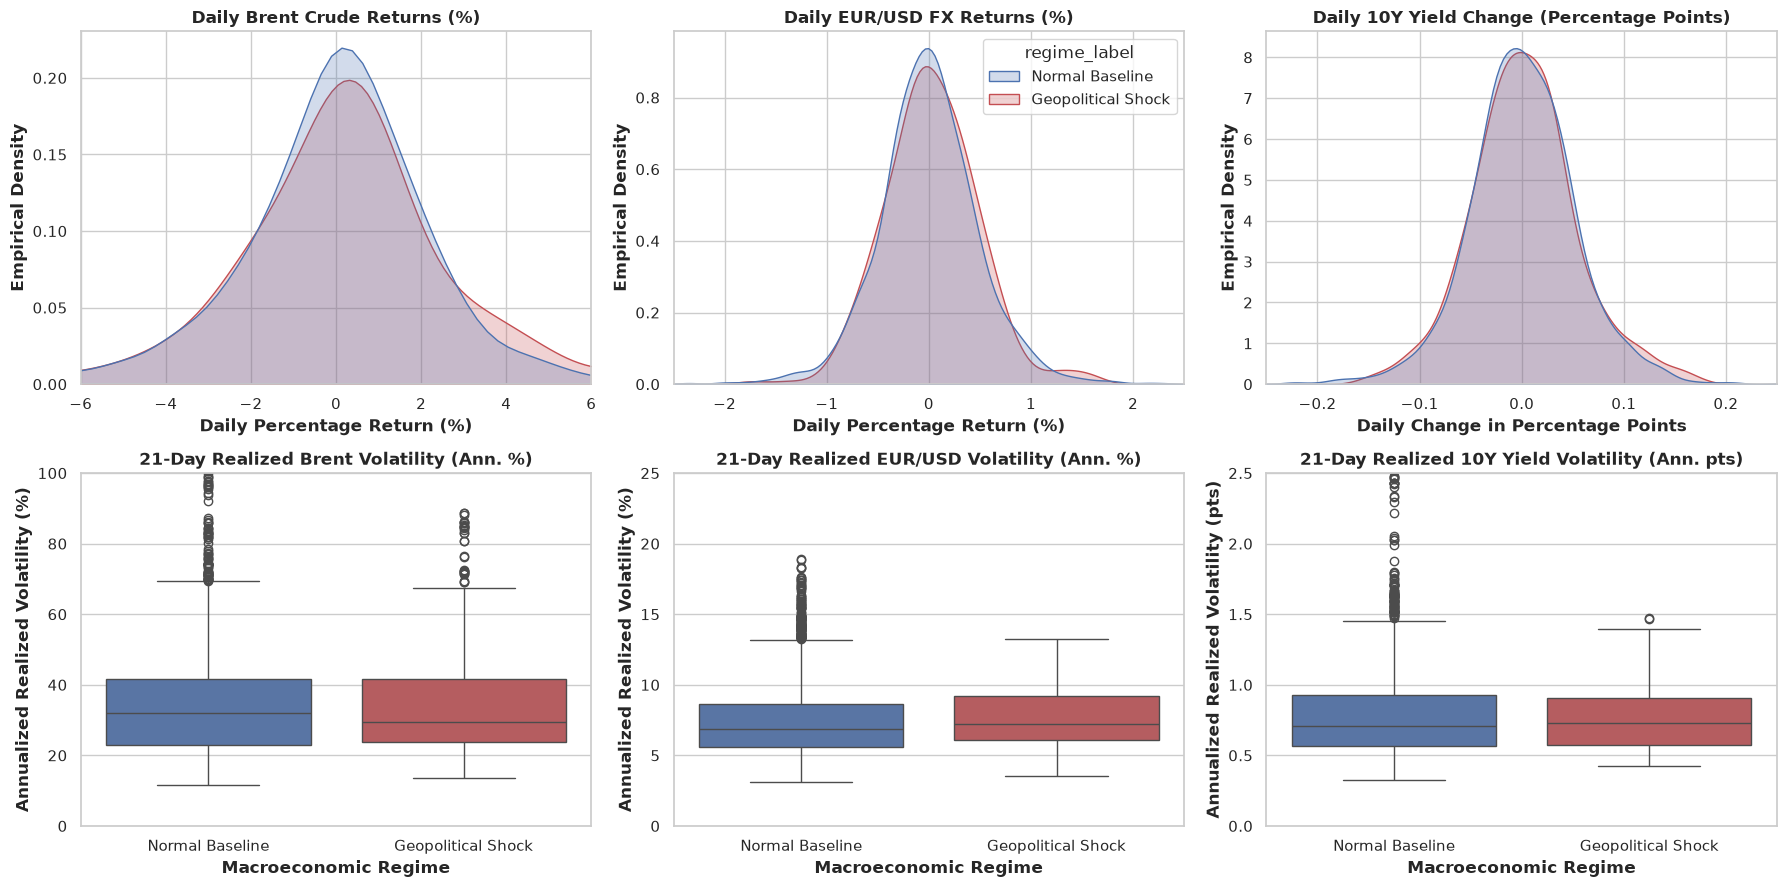

In [3]:
# 1. Daily macro distributions and 21-day rolling volatility grid (Brent, EUR/USD, 10Y Yields)
bronze_sql_path = BRONZE_DIR.replace("\\", "/")
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE daily_macro_regimes AS
    WITH shock_months AS (
        SELECT 
            strftime(month_date, '%Y-%m') AS ym, 
            is_geopolitical_shock_month
        FROM gold.fct_macro_regimes
    ),
    daily_brent AS (
        SELECT 
            CAST(Date AS DATE) AS date, 
            CAST(Close AS DOUBLE) AS brent_close 
        FROM read_csv_auto('{bronze_sql_path}/market_brent_daily.csv')
    ),
    daily_fx AS (
        SELECT 
            CAST(Date AS DATE) AS date, 
            CAST(Close AS DOUBLE) AS eur_usd_close 
        FROM read_csv_auto('{bronze_sql_path}/market_eur_usd_daily.csv')
    ),
    daily_yield AS (
        SELECT 
            CAST(Date AS DATE) AS date, 
            CAST(Close AS DOUBLE) AS yield_10y_close 
        FROM read_csv_auto('{bronze_sql_path}/market_treasury_10y_daily.csv')
    )
    SELECT 
        b.date,
        strftime(b.date, '%Y-%m') AS ym,
        COALESCE(s.is_geopolitical_shock_month, 0) AS is_shock_month,
        b.brent_close,
        f.eur_usd_close,
        y.yield_10y_close
    FROM daily_brent b
    LEFT JOIN daily_fx f ON b.date = f.date
    LEFT JOIN daily_yield y ON b.date = y.date
    LEFT JOIN shock_months s ON strftime(b.date, '%Y-%m') = s.ym
    ORDER BY b.date ASC;
""")

df_daily = con.execute("SELECT * FROM daily_macro_regimes WHERE brent_close IS NOT NULL").df()

# Compute daily returns and 21-day rolling annualized volatility
df_daily["brent_daily_ret"] = df_daily["brent_close"].pct_change() * 100
df_daily["eur_usd_daily_ret"] = df_daily["eur_usd_close"].pct_change() * 100
df_daily["yield_daily_diff"] = df_daily["yield_10y_close"].diff()

df_daily["brent_vol_21d"] = df_daily["brent_daily_ret"].rolling(21).std() * np.sqrt(252)
df_daily["fx_vol_21d"] = df_daily["eur_usd_daily_ret"].rolling(21).std() * np.sqrt(252)
df_daily["yield_vol_21d"] = df_daily["yield_daily_diff"].rolling(21).std() * np.sqrt(252)

df_daily["regime_label"] = df_daily["is_shock_month"].map({
    0: "Normal Baseline",
    1: "Geopolitical Shock"
})

palette_colors = {"Normal Baseline": "#4C72B0", "Geopolitical Shock": "#C44E52"}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Row 1: Daily Return Distributions
sns.kdeplot(data=df_daily, x="brent_daily_ret", hue="regime_label",
            common_norm=False, fill=True, palette=palette_colors, ax=axes[0, 0])
axes[0, 0].set_title("Daily Brent Crude Returns (%)", weight="bold")
axes[0, 0].set_xlabel("Daily Percentage Return (%)", weight="bold")
axes[0, 0].set_ylabel("Empirical Density", weight="bold")
axes[0, 0].set_xlim(-6, 6)
if axes[0, 0].get_legend():
    axes[0, 0].get_legend().remove()

sns.kdeplot(data=df_daily, x="eur_usd_daily_ret", hue="regime_label",
            common_norm=False, fill=True, palette=palette_colors, ax=axes[0, 1])
axes[0, 1].set_title("Daily EUR/USD FX Returns (%)", weight="bold")
axes[0, 1].set_xlabel("Daily Percentage Return (%)", weight="bold")
axes[0, 1].set_ylabel("Empirical Density", weight="bold")
axes[0, 1].set_xlim(-2.5, 2.5)

sns.kdeplot(data=df_daily, x="yield_daily_diff", hue="regime_label",
            common_norm=False, fill=True, palette=palette_colors, ax=axes[0, 2])
axes[0, 2].set_title("Daily 10Y Yield Change (Percentage Points)", weight="bold")
axes[0, 2].set_xlabel("Daily Change in Percentage Points", weight="bold")
axes[0, 2].set_ylabel("Empirical Density", weight="bold")
axes[0, 2].set_xlim(-0.25, 0.25)
if axes[0, 2].get_legend():
    axes[0, 2].get_legend().remove()

# Row 2: 21-Day Realized Annualized Volatility
sns.boxplot(data=df_daily.dropna(subset=["brent_vol_21d"]),
            x="regime_label", y="brent_vol_21d", hue="regime_label",
            palette=palette_colors, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("21-Day Realized Brent Volatility (Ann. %)", weight="bold")
axes[1, 0].set_xlabel("Macroeconomic Regime", weight="bold")
axes[1, 0].set_ylabel("Annualized Realized Volatility (%)", weight="bold")
axes[1, 0].set_ylim(0, 100)

sns.boxplot(data=df_daily.dropna(subset=["fx_vol_21d"]),
            x="regime_label", y="fx_vol_21d", hue="regime_label",
            palette=palette_colors, legend=False, ax=axes[1, 1])
axes[1, 1].set_title("21-Day Realized EUR/USD Volatility (Ann. %)", weight="bold")
axes[1, 1].set_xlabel("Macroeconomic Regime", weight="bold")
axes[1, 1].set_ylabel("Annualized Realized Volatility (%)", weight="bold")
axes[1, 1].set_ylim(0, 25)

sns.boxplot(data=df_daily.dropna(subset=["yield_vol_21d"]),
            x="regime_label", y="yield_vol_21d", hue="regime_label",
            palette=palette_colors, legend=False, ax=axes[1, 2])
axes[1, 2].set_title("21-Day Realized 10Y Yield Volatility (Ann. pts)", weight="bold")
axes[1, 2].set_xlabel("Macroeconomic Regime", weight="bold")
axes[1, 2].set_ylabel("Annualized Realized Volatility (pts)", weight="bold")
axes[1, 2].set_ylim(0, 2.5)

plt.tight_layout()
fig1_path = os.path.join(BASE_DIR, "reports", "figures", "figure1_market_distributions.png")
os.makedirs(os.path.dirname(fig1_path), exist_ok=True)
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()


## 2. Event Study Price Trajectories (Day -5 to +25)
Normalized price and yield dynamics around major historical geopolitical shock episodes (2022-02-24 and 2023-10-07).

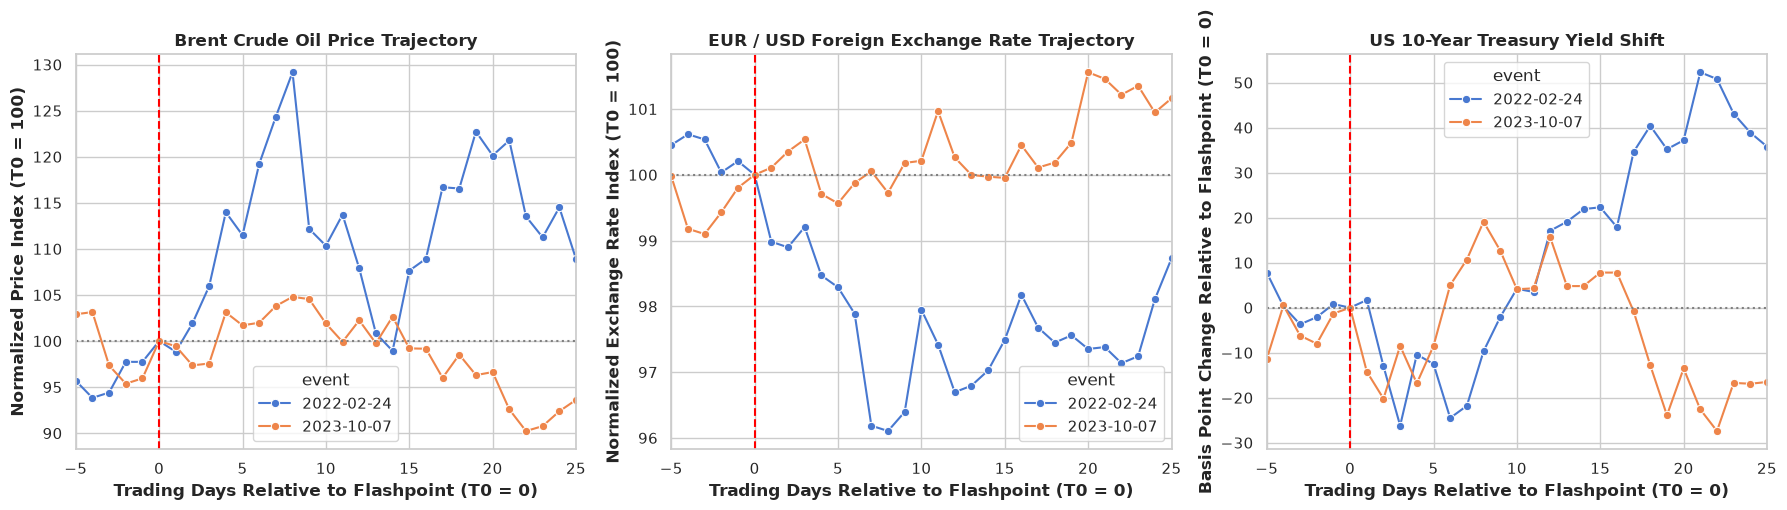

In [4]:
# 2. Event study price trajectory charts (Day -5 to +25)
event_dates = ["2022-02-24", "2023-10-07"]
event_traces = []

for ev in event_dates:
    ev_dt = pd.to_datetime(ev)
    sub = df_daily.copy()
    sub["dt"] = pd.to_datetime(sub["date"])
    sub = sub.sort_values("dt").reset_index(drop=True)
    
    idx_list = sub.index[sub["dt"] >= ev_dt]
    if len(idx_list) > 0:
        event_idx = idx_list[0]
        start_idx = max(0, event_idx - 5)
        end_idx = min(len(sub) - 1, event_idx + 25)
        window = sub.iloc[start_idx:end_idx + 1].copy()
        window["event_day"] = range(-(event_idx - start_idx), end_idx - event_idx + 1)
        
        base_brent = window[window["event_day"] == 0]["brent_close"].values[0]
        base_fx = window[window["event_day"] == 0]["eur_usd_close"].values[0]
        base_yield = window[window["event_day"] == 0]["yield_10y_close"].values[0]
        
        window["norm_brent"] = (window["brent_close"] / base_brent) * 100
        window["norm_fx"] = (window["eur_usd_close"] / base_fx) * 100
        window["diff_yield"] = (window["yield_10y_close"] - base_yield) * 100
        window["event"] = ev
        event_traces.append(window)

df_events = pd.concat(event_traces)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Brent Trajectory
sns.lineplot(data=df_events, x="event_day", y="norm_brent", hue="event", marker="o", ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", label="Flashpoint (T0 = 0)")
axes[0].axhline(100, color="gray", linestyle=":")
axes[0].set_title("Brent Crude Oil Price Trajectory", weight="bold")
axes[0].set_xlabel("Trading Days Relative to Flashpoint (T0 = 0)", weight="bold")
axes[0].set_ylabel("Normalized Price Index (T0 = 100)", weight="bold")
axes[0].set_xlim(-5, 25)

# 2. EUR/USD Trajectory
sns.lineplot(data=df_events, x="event_day", y="norm_fx", hue="event", marker="o", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].axhline(100, color="gray", linestyle=":")
axes[1].set_title("EUR / USD Foreign Exchange Rate Trajectory", weight="bold")
axes[1].set_xlabel("Trading Days Relative to Flashpoint (T0 = 0)", weight="bold")
axes[1].set_ylabel("Normalized Exchange Rate Index (T0 = 100)", weight="bold")
axes[1].set_xlim(-5, 25)

# 3. 10Y Yield Trajectory
sns.lineplot(data=df_events, x="event_day", y="diff_yield", hue="event", marker="o", ax=axes[2])
axes[2].axvline(0, color="red", linestyle="--")
axes[2].axhline(0, color="gray", linestyle=":")
axes[2].set_title("US 10-Year Treasury Yield Shift", weight="bold")
axes[2].set_xlabel("Trading Days Relative to Flashpoint (T0 = 0)", weight="bold")
axes[2].set_ylabel("Basis Point Change Relative to Flashpoint (T0 = 0)", weight="bold")
axes[2].set_xlim(-5, 25)

plt.tight_layout()
fig2_path = os.path.join(BASE_DIR, "reports", "figures", "figure2_event_study.png")
os.makedirs(os.path.dirname(fig2_path), exist_ok=True)
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()


## 3. HAC OLS Regressions: Tech CapEx vs. Macro Yields
OLS regressions estimating the sensitivity of quarterly software and R&D capital expenditure growth to interest rate shifts and geopolitical risk.

In [5]:
# 3. HAC OLS regression table for Software/R&D CapEx vs. macro yields
df_friction = con.execute("""
    SELECT 
        software_growth_qoq,
        rd_growth_qoq,
        total_ip_growth_qoq,
        avg_gpr_index,
        had_geopolitical_shock,
        avg_10y_yield,
        yield_qoq_change
    FROM gold.fct_innovation_friction
    WHERE yield_qoq_change IS NOT NULL
""").df()

X = sm.add_constant(df_friction[["yield_qoq_change", "avg_gpr_index"]])
model_sw = sm.OLS(df_friction["software_growth_qoq"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})
model_rd = sm.OLS(df_friction["rd_growth_qoq"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

print("=== HAC OLS REGRESSION: SOFTWARE CAPEX GROWTH QoQ ===")
print(model_sw.summary().tables[1])

print("\n=== HAC OLS REGRESSION: R&D INVESTMENT GROWTH QoQ ===")
print(model_rd.summary().tables[1])


=== HAC OLS REGRESSION: SOFTWARE CAPEX GROWTH QoQ ===
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5609      0.514      3.037      0.002       0.553       2.568
yield_qoq_change     0.8205      0.472      1.739      0.082      -0.104       1.745
avg_gpr_index        0.0049      0.004      1.296      0.195      -0.003       0.012

=== HAC OLS REGRESSION: R&D INVESTMENT GROWTH QoQ ===
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.8954      0.660      2.874      0.004       0.603       3.188
yield_qoq_change     0.5951      0.673      0.885      0.376      -0.723       1.913
avg_gpr_index        0.0010      0.005      0.183      0.855      -0.010       0.011


## 4. K-Means Labor Cluster Analysis (Strictly k=3)
Unsupervised machine learning segmentation of occupations across median wages, task intensity, and automation pressure.
Includes the cluster summary profile table and the economic archetype scatter plot.

=== K-MEANS CLUSTER SUMMARY PROFILES (k=3) ===
 cluster                       cluster_profile  occupation_count  mean_hourly_wage  mean_task_intensity  mean_automation_pressure  total_payroll_billions
       0            Hands-on & Service Workers               276             21.39                 2.76                     59.71                 2683.61
       1 Operational & Analytical Coordinators               308             29.39                 3.47                    102.45                 2859.58
       2    High-Earning Specialists & Leaders               112             58.84                 3.58                    212.48                 2502.45


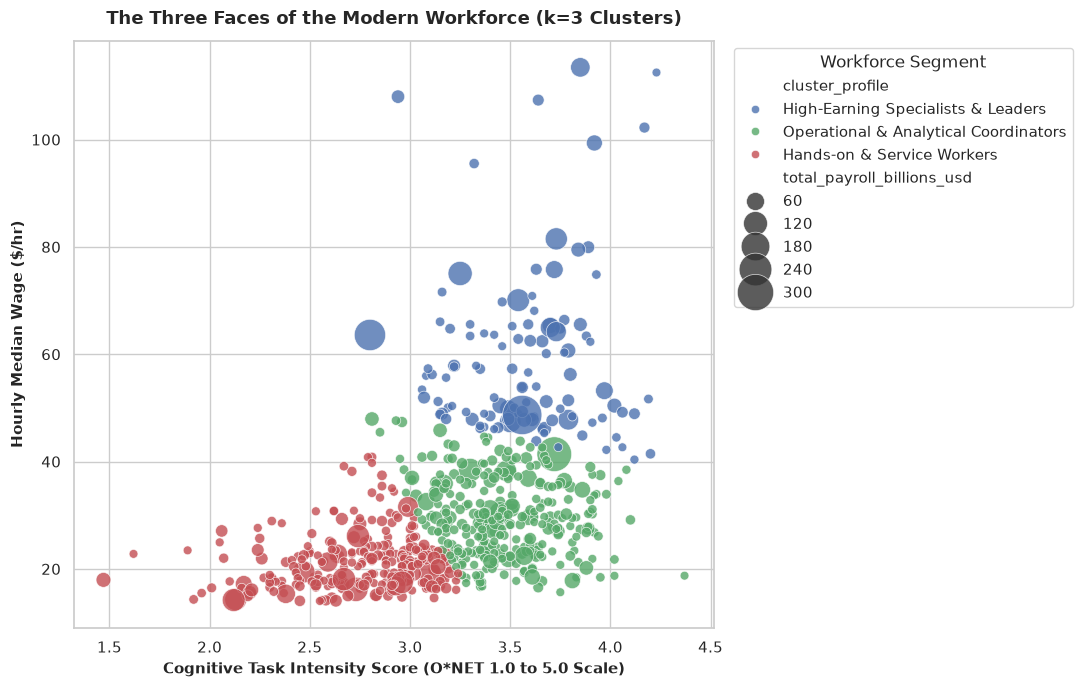

In [6]:
# 4. K-Means cluster analysis (summary profile table and scatter plot, strictly k=3)
df_occ = con.execute("""
    SELECT 
        soc_code,
        occupation_title,
        soc_major_group,
        hourly_median_wage,
        onet_task_intensity_score,
        total_payroll_billions_usd,
        automation_pressure_index
    FROM gold.fct_labor_automation_pressure
""").df()

features = ["hourly_median_wage", "onet_task_intensity_score", "automation_pressure_index"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_occ[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_occ["cluster"] = kmeans.fit_predict(X_scaled)

# Map clusters to economic archetype profiles based on median wage ordering
wage_ranks = df_occ.groupby("cluster")["hourly_median_wage"].mean().sort_values()
label_map = {
    wage_ranks.index[0]: "Hands-on & Service Workers",
    wage_ranks.index[1]: "Operational & Analytical Coordinators",
    wage_ranks.index[2]: "High-Earning Specialists & Leaders"
}
df_occ["cluster_profile"] = df_occ["cluster"].map(label_map)

# 1. Cluster Summary Profile Table
cluster_summary = df_occ.groupby(["cluster", "cluster_profile"]).agg(
    occupation_count=("soc_code", "count"),
    mean_hourly_wage=("hourly_median_wage", "mean"),
    mean_task_intensity=("onet_task_intensity_score", "mean"),
    mean_automation_pressure=("automation_pressure_index", "mean"),
    total_payroll_billions=("total_payroll_billions_usd", "sum")
).round(2).reset_index()

print("=== K-MEANS CLUSTER SUMMARY PROFILES (k=3) ===")
print(cluster_summary.to_string(index=False))

# 2. Cluster Scatter Plot Visualization
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_occ,
    x="onet_task_intensity_score",
    y="hourly_median_wage",
    hue="cluster_profile",
    size="total_payroll_billions_usd",
    sizes=(40, 800),
    palette=["#4C72B0", "#55A868", "#C44E52"],
    alpha=0.8
)
plt.title("The Three Faces of the Modern Workforce (k=3 Clusters)", fontsize=13, weight="bold", pad=12)
plt.xlabel("Cognitive Task Intensity Score (O*NET 1.0 to 5.0 Scale)", fontsize=11, weight="bold")
plt.ylabel("Hourly Median Wage ($/hr)", fontsize=11, weight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, title="Workforce Segment")
plt.tight_layout()
fig3_path = os.path.join(BASE_DIR, "reports", "figures", "figure3_workforce_clusters.png")
os.makedirs(os.path.dirname(fig3_path), exist_ok=True)
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()


## 5. The 2x2 Labor Friction Matrix: Augmentation Potential vs. Administrative Drag
Disaggregates task decomposition to identify high-leverage specialists constrained by administrative burden (Quadrant 2 bottlenecks).

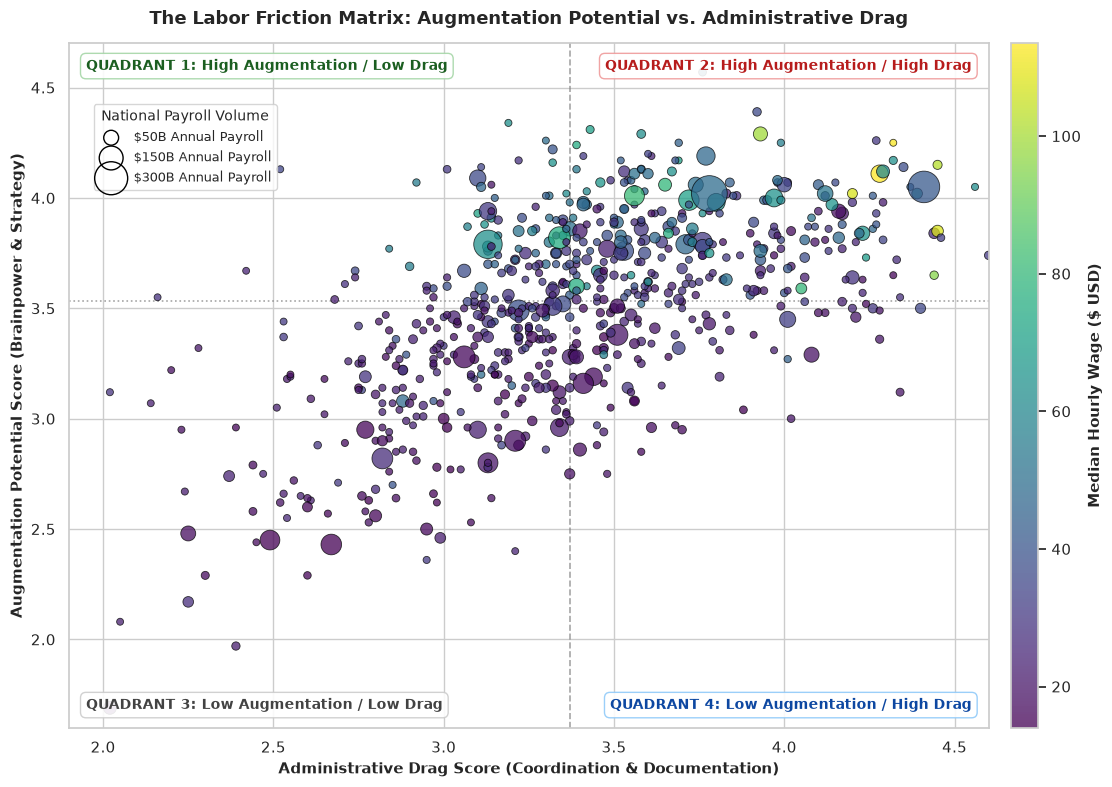

=== TOP QUADRANT 2 BOTTLENECK OCCUPATIONS (BY PAYROLL VOLUME) ===
                                                   occupation_title  hourly_median_wage  total_payroll_billions_usd  augmentation_score  admin_drag_score
                                    General and Operations Managers               48.69                      355.25                4.02              3.78
                                                  Registered Nurses               41.38                      273.31                4.05              4.41
                                                            Lawyers               70.08                      106.60                3.99              3.72
                          Computer and Information Systems Managers               81.50                      100.46                4.01              3.56
First-Line Supervisors of Office and Administrative Support Workers               30.50                       95.45                3.80              3.76
          

In [7]:
# 5. The 2x2 Labor Friction Matrix scatter plot and Top Quadrant 2 bottleneck table
df_labor_quadrants = con.execute("""
    SELECT 
        l.soc_code,
        l.occupation_title,
        l.soc_major_group,
        l.hourly_median_wage,
        l.total_payroll_billions_usd,
        t.augmentation_score,
        t.admin_drag_score,
        (t.augmentation_score / t.admin_drag_score) AS leverage_ratio
    FROM gold.fct_labor_automation_pressure l
    INNER JOIN silver.fact_labor_task_decomposition t ON l.soc_code = t.soc_code
""").df()

aug_median = df_labor_quadrants["augmentation_score"].median()
drag_median = df_labor_quadrants["admin_drag_score"].median()

fig, ax = plt.subplots(figsize=(12, 8))

# Reference median dividers
ax.axvline(drag_median, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, zorder=1)
ax.axhline(aug_median, color="gray", linestyle=":", linewidth=1.2, alpha=0.7, zorder=1)

# Rescaled point sizes: bubbles do not overlap into a solid mass
sizes = df_labor_quadrants["total_payroll_billions_usd"] * 1.8 + 25

scatter = ax.scatter(
    df_labor_quadrants["admin_drag_score"],
    df_labor_quadrants["augmentation_score"],
    s=sizes,
    c=df_labor_quadrants["hourly_median_wage"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.6,
    zorder=2
)

# Standalone continuous vertical colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.02, aspect=25)
cbar.set_label("Median Hourly Wage ($ USD)", fontsize=11, weight="bold")

# Balanced padding on axes limits
ax.set_xlim(1.9, 4.6)
ax.set_ylim(1.6, 4.7)

# Quadrant labels in clean, white-backed watermark boxes in outer corners
ax.text(1.95, 4.63, "QUADRANT 1: High Augmentation / Low Drag",
        fontsize=10, weight="bold", color="#1b5e20", va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#a5d6a7", alpha=0.9))

ax.text(4.55, 4.63, "QUADRANT 2: High Augmentation / High Drag",
        fontsize=10, weight="bold", color="#b71c1c", va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#ef9a9a", alpha=0.9))

ax.text(1.95, 1.67, "QUADRANT 3: Low Augmentation / Low Drag",
        fontsize=10, weight="bold", color="#424242", va="bottom", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.9))

ax.text(4.55, 1.67, "QUADRANT 4: Low Augmentation / High Drag",
        fontsize=10, weight="bold", color="#0d47a1", va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#90caf9", alpha=0.9))

# Bubble-size reference legend with only 3 points ($50B, $150B, $300B)
handles = []
for p_val in [50, 150, 300]:
    h = ax.scatter([], [], s=p_val * 1.8 + 25, c="none", edgecolors="black", linewidth=1.0, label=f"${p_val}B Annual Payroll")
    handles.append(h)

ax.legend(handles=handles, title="National Payroll Volume", loc="upper left", bbox_to_anchor=(0.02, 0.92),
          frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=9, title_fontsize=10)

ax.set_title("The Labor Friction Matrix: Augmentation Potential vs. Administrative Drag", fontsize=13, weight="bold", pad=14)
ax.set_xlabel("Administrative Drag Score (Coordination & Documentation)", fontsize=11, weight="bold")
ax.set_ylabel("Augmentation Potential Score (Brainpower & Strategy)", fontsize=11, weight="bold")

plt.tight_layout()
fig4_path = os.path.join(BASE_DIR, "reports", "figures", "figure4_labor_friction_matrix.png")
os.makedirs(os.path.dirname(fig4_path), exist_ok=True)
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()

# Top Quadrant 2 Bottleneck Occupations
df_q2 = con.execute(f"""
    SELECT 
        l.soc_code,
        l.occupation_title,
        l.soc_major_group,
        l.hourly_median_wage,
        l.total_payroll_billions_usd,
        t.augmentation_score,
        t.admin_drag_score
    FROM gold.fct_labor_automation_pressure l
    INNER JOIN silver.fact_labor_task_decomposition t ON l.soc_code = t.soc_code
    WHERE t.augmentation_score >= {aug_median}
      AND t.admin_drag_score >= {drag_median}
    ORDER BY l.total_payroll_billions_usd DESC
    LIMIT 15;
""").df()

print("=== TOP QUADRANT 2 BOTTLENECK OCCUPATIONS (BY PAYROLL VOLUME) ===")
print(df_q2[["occupation_title", "hourly_median_wage", "total_payroll_billions_usd", "augmentation_score", "admin_drag_score"]].to_string(index=False))


## Teardown & Catalog Connection Management

In [8]:
# Explicitly close DuckDB connection
con.close()
print("DuckDB connection successfully closed.")


DuckDB connection successfully closed.
